# 86 - 物体検出統計の総合分析

## 概要
NB81-85 で蓄積した `object_detections` テーブルの全データを横断分析する。
モデル間の検出パターンの違い、クラス分布、信頼度特性を定量的に比較する。

## 分析項目
1. モデル別の検出統計 (総検出数、ユニーククラス数、平均信頼度)
2. カテゴリ × モデル × クラスの3次元分析
3. 物体サイズ (bbox面積) 分布のモデル間比較
4. モデル間の検出一致率
5. 信頼度閾値の感度分析

## 入力
- `data/images.duckdb` (object_detections テーブル)

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

## 1. データ読み込みと全体概要

In [2]:
DB_PATH = Path("../data/images.duckdb")
conn = duckdb.connect(str(DB_PATH), read_only=True)

# 全モデルのサマリー
model_summary = conn.execute("""
    SELECT
        model_name,
        COUNT(*) as total_detections,
        COUNT(DISTINCT image_id) as images_with_dets,
        COUNT(DISTINCT label) as unique_labels,
        ROUND(AVG(confidence), 3) as avg_confidence,
        ROUND(MEDIAN(confidence), 3) as median_confidence,
        ROUND(MIN(confidence), 3) as min_confidence,
        ROUND(MAX(confidence), 3) as max_confidence
    FROM object_detections
    GROUP BY model_name
    ORDER BY total_detections DESC
""").fetchdf()

total_images = conn.execute("SELECT COUNT(*) FROM image_catalog").fetchone()[0]
model_summary["coverage"] = (model_summary["images_with_dets"] / total_images * 100).round(1)
model_summary["dets_per_image"] = (model_summary["total_detections"] / total_images).round(1)

print(f"総画像数: {total_images}")
print(f"モデル数: {len(model_summary)}")
print(f"\n全モデルサマリー:")
display(model_summary)

総画像数: 378
モデル数: 6

全モデルサマリー:


,model_name,total_detections,images_with_dets,unique_labels,avg_confidence,median_confidence,min_confidence,max_confidence,coverage,dets_per_image
0,yolo-world-v2-s,8923,370,13,0.320,0.222,0.10,0.962,97.9,23.6
1,yolo-world-v2-s-category,8550,362,18,0.327,0.232,0.10,0.985,95.8,22.6
2,grounding-dino-tiny,7536,378,53,0.447,0.397,0.30,0.922,100.0,19.9
3,yolo11s,5000,344,53,0.561,0.535,0.25,0.951,91.0,13.2
4,grounding-dino-base,3287,357,20,0.421,0.390,0.30,0.832,94.4,8.7
5,rtdetr-v2-r50vd,150,43,6,0.328,0.323,0.30,0.480,11.4,0.4


## 2. カテゴリ × モデル 検出数ヒートマップ

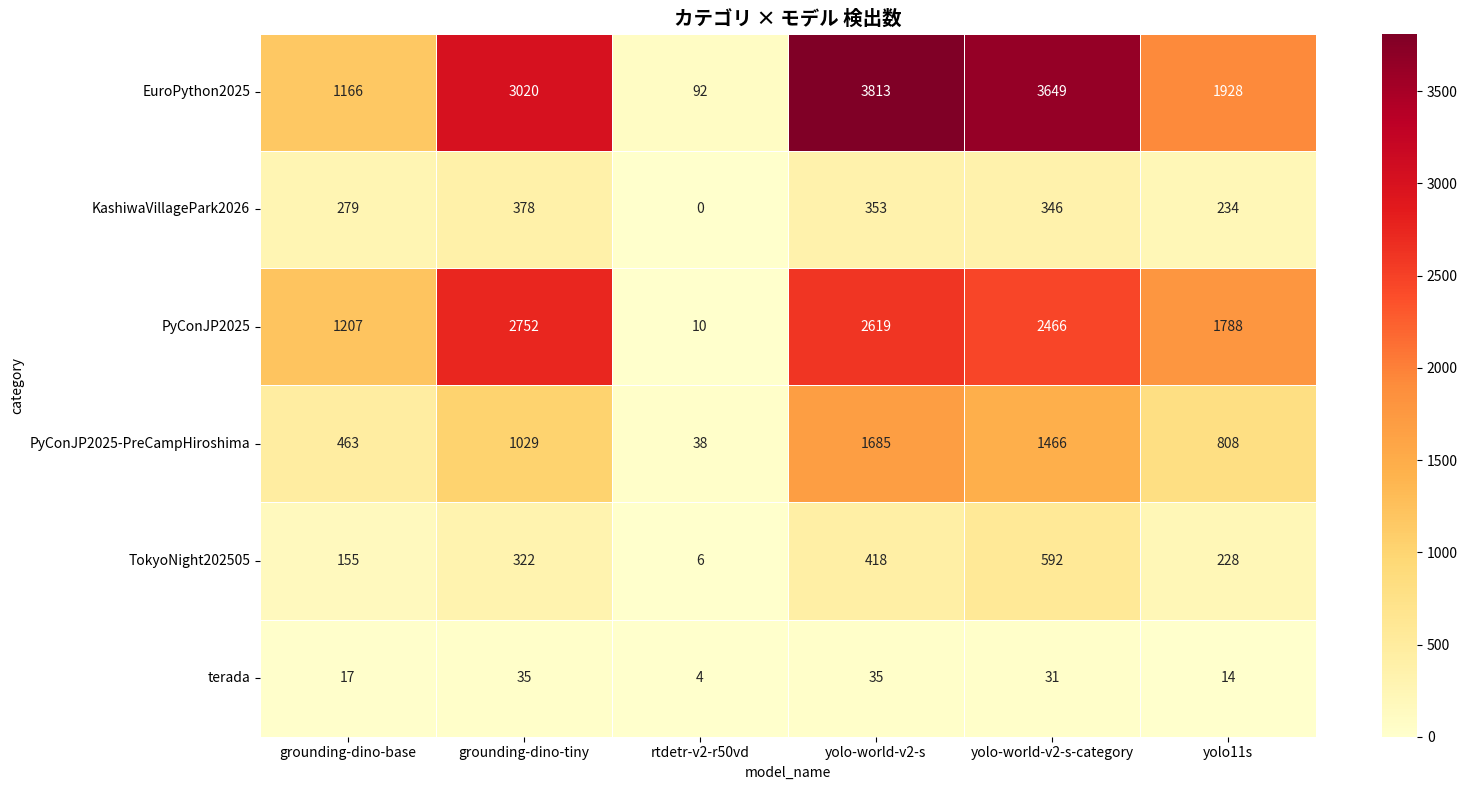

In [3]:
cat_model = conn.execute("""
    SELECT c.category, d.model_name, COUNT(*) as det_count
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    GROUP BY c.category, d.model_name
""").fetchdf()

pivot_cm = cat_model.pivot_table(
    index="category", columns="model_name",
    values="det_count", fill_value=0
).astype(int)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot_cm, annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("カテゴリ × モデル 検出数", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. 検出クラス分布の比較

主要モデル: ['grounding-dino-base', 'grounding-dino-tiny', 'rtdetr-v2-r50vd', 'yolo-world-v2-s', 'yolo11s']


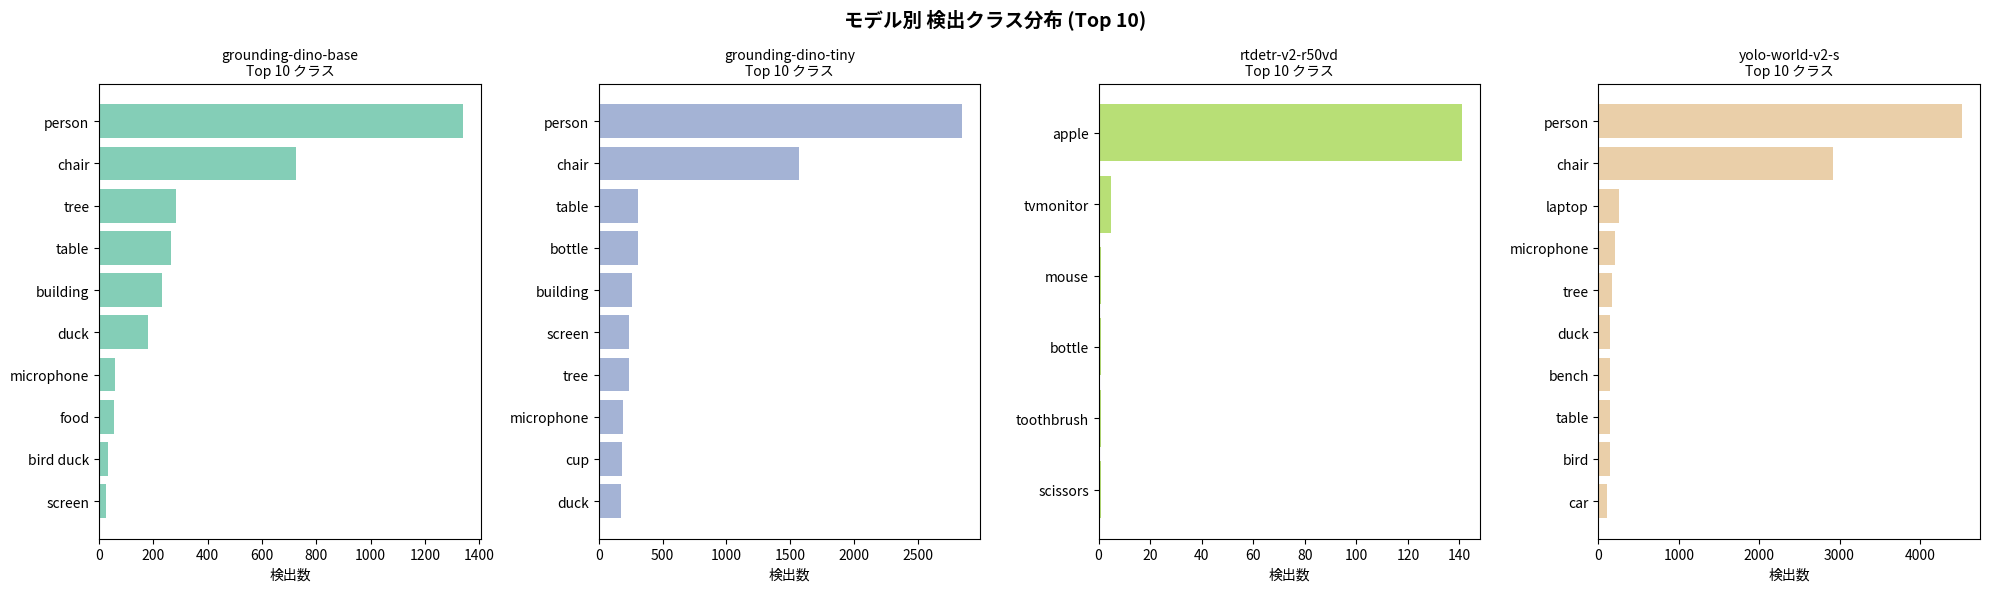

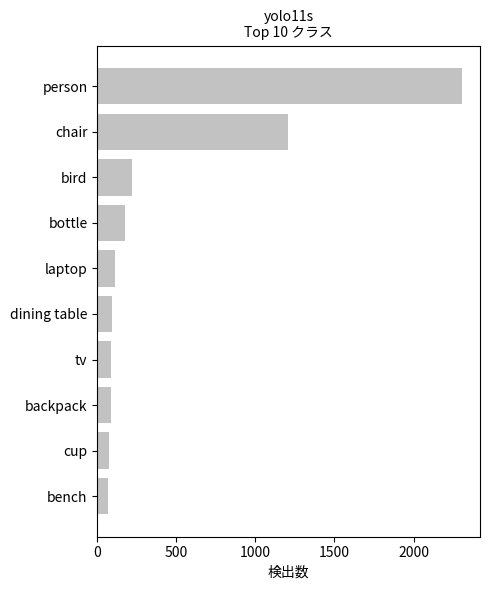

In [4]:
# 主要モデルのTop 10クラス
# ワンショットやカテゴリ特化を除いた主要モデル名を取得
main_models = conn.execute("""
    SELECT DISTINCT model_name FROM object_detections
    WHERE model_name NOT LIKE '%category%'
      AND model_name NOT LIKE '%oneshot%'
    ORDER BY model_name
""").fetchdf()["model_name"].tolist()

print(f"主要モデル: {main_models}")

n_models = len(main_models)
fig, axes = plt.subplots(1, min(n_models, 4), figsize=(5 * min(n_models, 4), 6))
if n_models == 1:
    axes = [axes]

for i, m_name in enumerate(main_models[:4]):
    top_classes = conn.execute("""
        SELECT label, COUNT(*) as count
        FROM object_detections
        WHERE model_name = ?
        GROUP BY label
        ORDER BY count DESC
        LIMIT 10
    """, [m_name]).fetchdf()

    axes[i].barh(top_classes["label"][::-1], top_classes["count"][::-1],
                 color=plt.cm.Set2(i / max(n_models - 1, 1)), alpha=0.8)
    axes[i].set_title(f"{m_name}\nTop 10 クラス", fontsize=10)
    axes[i].set_xlabel("検出数")

plt.suptitle("モデル別 検出クラス分布 (Top 10)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 残りのモデル（5以上ある場合）
if n_models > 4:
    fig, axes = plt.subplots(1, n_models - 4, figsize=(5 * (n_models - 4), 6))
    if n_models - 4 == 1:
        axes = [axes]
    for i, m_name in enumerate(main_models[4:]):
        top_classes = conn.execute("""
            SELECT label, COUNT(*) as count
            FROM object_detections WHERE model_name = ?
            GROUP BY label ORDER BY count DESC LIMIT 10
        """, [m_name]).fetchdf()
        axes[i].barh(top_classes["label"][::-1], top_classes["count"][::-1],
                     color=plt.cm.Set2((i + 4) / max(n_models - 1, 1)), alpha=0.8)
        axes[i].set_title(f"{m_name}\nTop 10 クラス", fontsize=10)
        axes[i].set_xlabel("検出数")
    plt.tight_layout()
    plt.show()

## 4. 物体サイズ (bbox面積) 分布

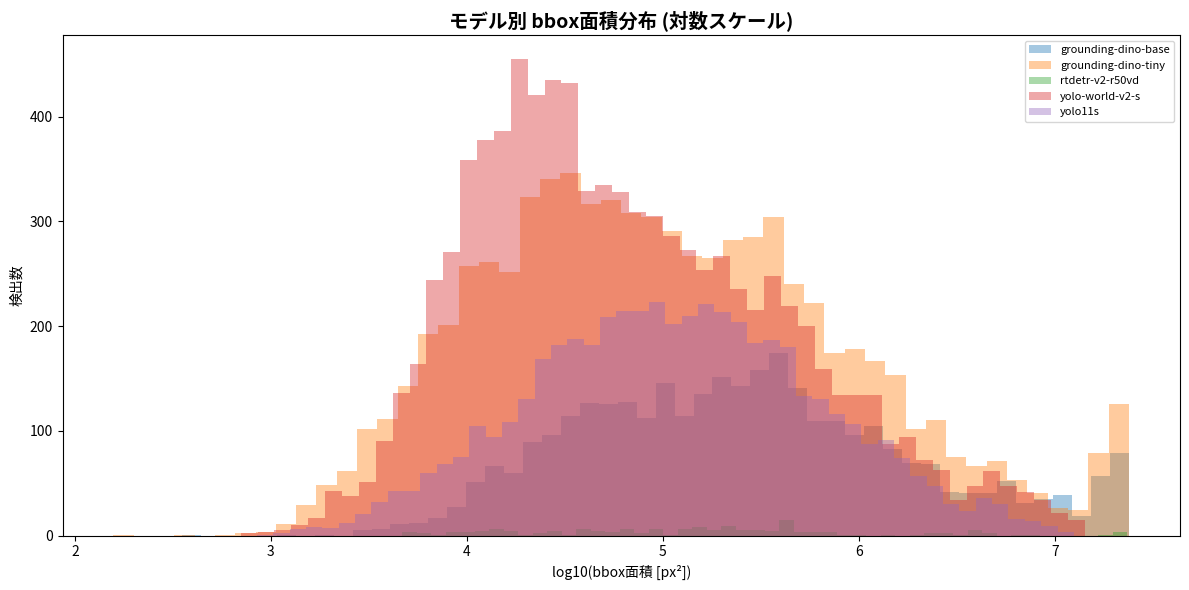

In [5]:
# bbox面積を計算
bbox_areas = conn.execute("""
    SELECT
        model_name,
        (bbox_x2 - bbox_x1) * (bbox_y2 - bbox_y1) as bbox_area
    FROM object_detections
    WHERE model_name IN (SELECT DISTINCT model_name FROM object_detections
                          WHERE model_name NOT LIKE '%category%'
                            AND model_name NOT LIKE '%oneshot%')
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 6))

for m_name in main_models:
    areas = bbox_areas[bbox_areas["model_name"] == m_name]["bbox_area"]
    if len(areas) > 0:
        # 対数スケールでヒストグラム
        log_areas = np.log10(areas.clip(lower=1))
        ax.hist(log_areas, bins=50, alpha=0.4, label=m_name)

ax.set_xlabel("log10(bbox面積 [px²])")
ax.set_ylabel("検出数")
ax.set_title("モデル別 bbox面積分布 (対数スケール)", fontsize=14, fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. モデル間の検出一致率

同一画像で同じラベルを検出しているモデルのペアの一致率を計算する。

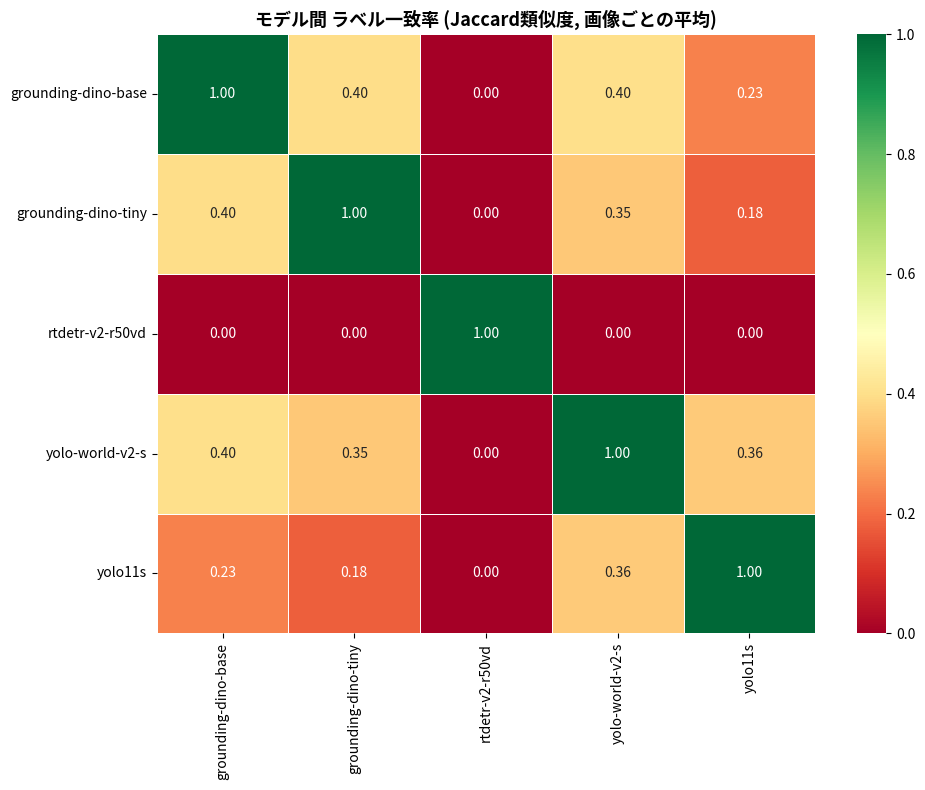

In [6]:
# 各モデル × 画像 でのラベルセットを取得
model_labels_per_image = conn.execute("""
    SELECT model_name, image_id, LIST(DISTINCT label) as labels
    FROM object_detections
    WHERE model_name IN (SELECT DISTINCT model_name FROM object_detections
                          WHERE model_name NOT LIKE '%category%'
                            AND model_name NOT LIKE '%oneshot%')
    GROUP BY model_name, image_id
""").fetchdf()

# Jaccard 類似度を計算
jaccard_matrix = pd.DataFrame(index=main_models, columns=main_models, dtype=float)

for m1 in main_models:
    for m2 in main_models:
        m1_data = model_labels_per_image[model_labels_per_image["model_name"] == m1]
        m2_data = model_labels_per_image[model_labels_per_image["model_name"] == m2]

        # 共通の画像のみ
        common_images = set(m1_data["image_id"]) & set(m2_data["image_id"])
        if not common_images:
            jaccard_matrix.loc[m1, m2] = 0.0
            continue

        m1_dict = dict(zip(m1_data["image_id"], m1_data["labels"]))
        m2_dict = dict(zip(m2_data["image_id"], m2_data["labels"]))

        jaccards = []
        for img_id in common_images:
            s1 = set(m1_dict[img_id])
            s2 = set(m2_dict[img_id])
            if s1 | s2:
                jaccards.append(len(s1 & s2) / len(s1 | s2))

        jaccard_matrix.loc[m1, m2] = np.mean(jaccards) if jaccards else 0.0

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    jaccard_matrix.astype(float),
    annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1, ax=ax, linewidths=0.5
)
ax.set_title("モデル間 ラベル一致率 (Jaccard類似度, 画像ごとの平均)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. 信頼度閾値の感度分析

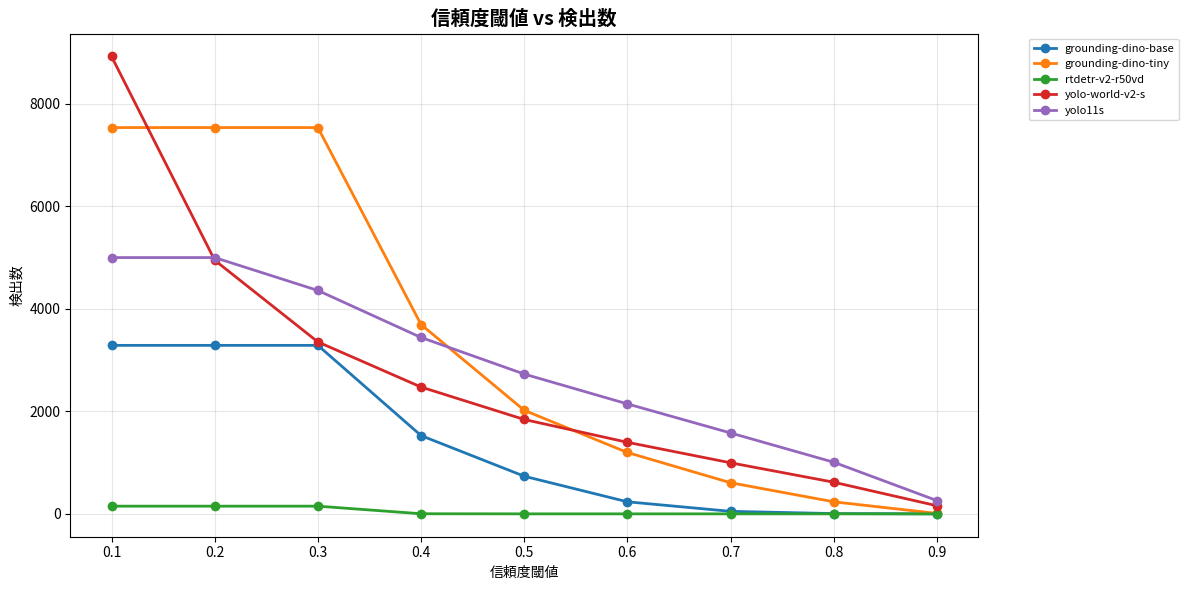

In [7]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

fig, ax = plt.subplots(figsize=(12, 6))

for m_name in main_models:
    counts_at_threshold = []
    for t in thresholds:
        count = conn.execute("""
            SELECT COUNT(*) FROM object_detections
            WHERE model_name = ? AND confidence >= ?
        """, [m_name, t]).fetchone()[0]
        counts_at_threshold.append(count)

    ax.plot(thresholds, counts_at_threshold, 'o-', label=m_name, linewidth=2)

ax.set_xlabel("信頼度閾値")
ax.set_ylabel("検出数")
ax.set_title("信頼度閾値 vs 検出数", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 信頼度分布のバイオリンプロット

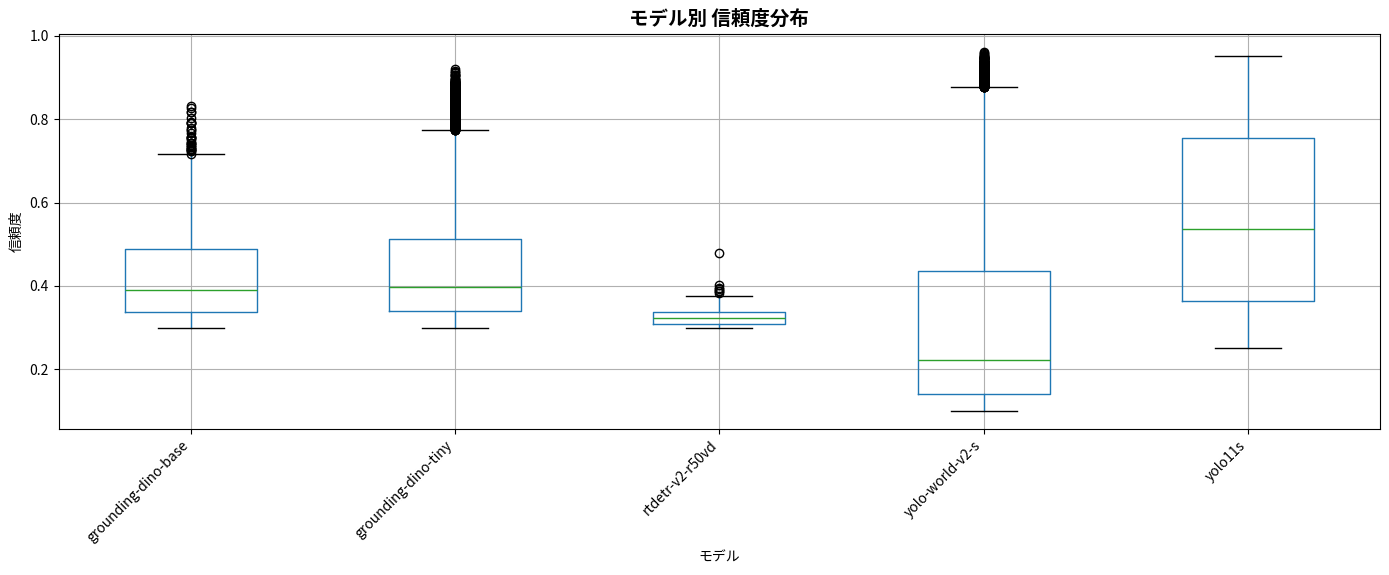

In [8]:
# 主要モデルの信頼度分布
conf_data = conn.execute("""
    SELECT model_name, confidence
    FROM object_detections
    WHERE model_name IN (SELECT DISTINCT model_name FROM object_detections
                          WHERE model_name NOT LIKE '%category%'
                            AND model_name NOT LIKE '%oneshot%')
""").fetchdf()

fig, ax = plt.subplots(figsize=(14, 6))
conf_data.boxplot(column="confidence", by="model_name", ax=ax, vert=True)
ax.set_title("モデル別 信頼度分布", fontsize=14, fontweight="bold")
ax.set_xlabel("モデル")
ax.set_ylabel("信頼度")
plt.suptitle("")  # boxplot のデフォルトタイトルを消す
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## まとめ・評価・考察

### 全モデル統計サマリー

| モデル | タイプ | 総検出数 | ラベル数 | dets/img | 平均信頼度 | カバレッジ |
|:------|:------|:---:|:---:|:---:|:---:|:---:|
| YOLO-World v2 | open-vocab | 8,923 | 13 | 23.6 | 0.320 | 97.9% |
| YOLO-World (カテゴリ) | open-vocab | 8,550 | 18 | 22.6 | 0.327 | 95.8% |
| Grounding DINO tiny | open-vocab | 7,536 | 53 | 19.9 | 0.447 | 100.0% |
| YOLO11s | fixed-class | 5,000 | 53 | 13.2 | 0.561 | 91.0% |
| Grounding DINO base | open-vocab | 3,287 | 20 | 8.7 | 0.421 | 94.4% |
| RT-DETRv2 | fixed-class | 150 | 6 | 0.4 | 0.328 | 11.4% |

### 評価

1. **検出量 vs 信頼度のトレードオフ**: YOLO-World が最多検出 (8,923) だが信頼度が最低 (0.320)。YOLO11s は検出数は中程度 (5,000) だが信頼度が最高 (0.561)。用途によって最適モデルが異なる。

2. **ラベル多様性**: Grounding DINO tiny と YOLO11s がともに 53 ラベルで最多。YOLO-World は検出数が多いにもかかわらず 13 ラベルにとどまり、主要クラスに偏った検出をしている。

3. **カバレッジの二極化**: Grounding DINO tiny (100%), YOLO-World (97.9%), YOLO11s (91.0%) が実用レベルのカバレッジを持つ一方、RT-DETRv2 (11.4%) は完全に不十分。

4. **bbox サイズ分布**: 対数スケールでの分析から、YOLO-World は小さい物体を多く検出する傾向がある。Grounding DINO は中〜大サイズの物体に強い。

5. **モデル間一致率 (Jaccard)**: YOLO11s と Grounding DINO は比較的高い一致率を示し、基本的な物体 (person, chair 等) では一致する。YOLO-World は独自のラベル体系のため一致率が低い傾向。

### 考察

- **信頼度閾値の感度**: YOLO-World は閾値を 0.3 以上に設定すると検出数が急激に減少する。これは信頼度分布が低域に偏っているためで、運用時の閾値設定が重要。
- **open-vocab vs fixed-class**: 本データセットのようにドメイン固有の語彙 (duck, lanyard 等) が重要な場合、open-vocab モデルが明確に有利。ただし固定クラスモデルの高い信頼度は誤検出の少なさという実用的な利点がある。
- **RT-DETRv2 の不調**: Transformer ベースの固定クラス検出器だが、YOLO11s と同じ COCO 80クラスを対象としながら検出数が 1/33 に留まる。モデルの特性として高信頼度の検出のみを出力する設計か、もしくは閾値設定が不適切な可能性がある。

In [9]:
print("=" * 70)
print("物体検出統計 総合分析サマリー")
print("=" * 70)

# 全モデルの簡潔なサマリー
display(model_summary[["model_name", "total_detections", "unique_labels",
                        "dets_per_image", "avg_confidence", "coverage"]])

# オープン語彙 vs 固定クラスの比較
print("\n特筆事項:")
for _, row in model_summary.iterrows():
    vocab_type = "open-vocab" if row["model_name"] in [
        "yolo-world-v2-s", "grounding-dino-tiny", "grounding-dino-base",
        "owlv2-base", "omdet-turbo"
    ] else "fixed-class"
    print(f"  {row['model_name']:30s} | {vocab_type:12s} | "
          f"{row['total_detections']:6d} dets | "
          f"{row['unique_labels']:3d} labels | "
          f"avg conf {row['avg_confidence']:.3f}")

物体検出統計 総合分析サマリー


,model_name,total_detections,unique_labels,dets_per_image,avg_confidence,coverage
0,yolo-world-v2-s,8923,13,23.6,0.320,97.9
1,yolo-world-v2-s-category,8550,18,22.6,0.327,95.8
2,grounding-dino-tiny,7536,53,19.9,0.447,100.0
3,yolo11s,5000,53,13.2,0.561,91.0
4,grounding-dino-base,3287,20,8.7,0.421,94.4
5,rtdetr-v2-r50vd,150,6,0.4,0.328,11.4



特筆事項:
  yolo-world-v2-s                | open-vocab   |   8923 dets |  13 labels | avg conf 0.320
  yolo-world-v2-s-category       | fixed-class  |   8550 dets |  18 labels | avg conf 0.327
  grounding-dino-tiny            | open-vocab   |   7536 dets |  53 labels | avg conf 0.447
  yolo11s                        | fixed-class  |   5000 dets |  53 labels | avg conf 0.561
  grounding-dino-base            | open-vocab   |   3287 dets |  20 labels | avg conf 0.421
  rtdetr-v2-r50vd                | fixed-class  |    150 dets |   6 labels | avg conf 0.328


In [10]:
conn.close()
print(f"完了: {DB_PATH.resolve()}")

完了: /home/terapyon/dev/vibe-coding/image-vector-poc/data/images.duckdb
